# Data Analysis: Coupled Pendulums and Beat Dynamics

## Project Overview
This project investigates the dynamics of coupled mechanical oscillators, focusing on the characterization of in-phase, out-of-phase, and beat mode oscillations. The analysis determines the degree of coupling and explores energy exchange between oscillators.

### Key Areas of Investigation:
1. **Normal Modes**: Analyzing oscillation periods for in-phase ($T_1$) and out-of-phase ($T_2$) configurations.
2. **Beat Dynamics**: Characterizing the beat period ($T_s$) and the modulation of oscillation amplitudes.
3. **Coupling Strength**: Calculating the degree of coupling ($k$) based on frequency shifts between normal modes.
4. **Automated Peak Detection**: Implementing robust numerical methods for signal processing and period determination from experimental voltage data.

---

## Task 1(a): Oscillation period $T_1$ of in-phase oscillations

This notebook evaluates the **in-phase oscillations** of the coupled pendulums
for one spring position, using the three datasets

- `in_1_6_0`
- `in_1_4_0`
- `in_1_2_0`

Task 1

> 1. Measure for three different positions of the coupling spring:  
> &nbsp;&nbsp;&nbsp;&nbsp;**a)** the oscillation period $T_1$ of in-phase oscillations,  
> &nbsp;&nbsp;&nbsp;&nbsp;**b)** the oscillation period $T_2$ of out-of-phase oscillations,  
> &nbsp;&nbsp;&nbsp;&nbsp;**c)** the oscillation period $T$ of the beat mode oscillation and  
> &nbsp;&nbsp;&nbsp;&nbsp;**d)** the beat period $T_S$.  



#### 1. Imports and basic settings

We use:
- `pandas` for loading the data files,
- `numpy` for numerical operations,
- `matplotlib` for plotting,
- a slightly more robust **smoothed peak finder** (no SciPy required).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit nicer
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


#### 2. Helper functions


##### 2.1 Loading the data

Each file (e.g. `in_1_6_0`) is a tab-separated text file with German decimal
commas and the columns

- `t (s)` – time in seconds  
- `U1(V)` – voltage from pendulum 1 (proportional to angle)  
- `U2(V)` – voltage from pendulum 2

We convert commas to dots using `decimal=','` and keep only the time axis and
one signal (here `U1(V)`).


In [4]:
def load_run(filename, use_column="U1(V)"):
    
    df = pd.read_csv(
        filename,
        sep="\t",
        decimal=",",
    )
    t = df["t (s)"].to_numpy()
    y = df[use_column].to_numpy()
    return t, y


#### 2.2 Smoothing and peak detection



1. **Smooth** the signal with a centred moving average.
2. Run a simple local-maximum peak finder on the **smoothed** signal.
3. Enforce a minimum distance in samples between neighbouring peaks.

This reliably gives **one peak per oscillation** for these data.


In [5]:
def smooth_signal(y, window=51):
    """Smooth the signal with a centred moving average.

    Parameters
    ----------
    y : array-like
        Input signal.
    window : int
        Window size (number of points, should be odd).
    """
    if window <= 1:
        return np.asarray(y)
    s = pd.Series(y).rolling(window=window, center=True).mean()
    # Fill NaNs at the edges by nearest valid values
    s = s.bfill().ffill()
    return s.to_numpy()


def find_peaks_simple(y, height=None, min_distance=10):
    """Very simple 1D peak finder on a *smoothed* signal.

    Parameters
    ----------
    y : array-like
        Signal values (preferably already smoothed).
    height : float or None
        Minimum required peak height. If None, a default is chosen as
        the median of the signal.
    min_distance : int
        Minimum number of samples between two neighbouring peaks.

    Returns
    -------
    peaks : np.ndarray of int
        Indices of detected peaks in the array.
    """
    y = np.asarray(y)
    n = len(y)
    if height is None:
        height = np.median(y)

    peaks = []
    last_peak = -min_distance
    for i in range(1, n - 1):
        if i - last_peak < min_distance:
            continue
        if y[i] > height and y[i] > y[i - 1] and y[i] >= y[i + 1]:
            peaks.append(i)
            last_peak = i
    return np.array(peaks, dtype=int)


def estimate_period_from_peaks(t, y, smooth_window=200, min_distance_factor=0.4):
    """
    Estimate oscillation period from successive peaks.

    Steps:
    1. Smooth y with a moving average of length `smooth_window`.
    2. Choose a minimum peak distance based on the total length
       of the time series (we expect ~10–20 oscillations in 20 s).
    3. Find peaks on the smoothed signal.
    4. Compute mean and standard deviation of the peak-to-peak intervals.
    """
    y_s = smooth_signal(y, window=smooth_window)

    # Heuristic for min_distance: assume about ~12 oscillations in record
    approx_n_osc = 12
    base_distance = len(y) / approx_n_osc
    min_distance = int(base_distance * min_distance_factor)
    min_distance = max(min_distance, 10)

    peaks = find_peaks_simple(y_s, height=None, min_distance=min_distance)
    if len(peaks) < 2:
        raise RuntimeError("Not enough peaks found to estimate a period.")

    peak_times = t[peaks]
    dt = np.diff(peak_times)
    return dt.mean(), dt.std(ddof=1), peaks, y_s


### 3. Load the in-phase datasets (Task 1a)

For the chosen spring position (here: spring position 1) we have three
in-phase runs with different initial amplitudes:

- `in_1_6_0` – initial angle 6°  
- `in_1_4_0` – initial angle 4°  
- `in_1_2_0` – initial angle 2°  

We load them and inspect the first few data points.


In [6]:
filenames = ["in_1_6_0", "in_1_4_0", "in_1_2_0"]

runs = {}
for fname in filenames:
    t, y = load_run(fname, use_column="U1(V)")
    runs[fname] = (t, y)
    print(f"{fname}: {len(t)} samples from t = {t[0]:.3f} s to {t[-1]:.3f} s")


in_1_6_0: 100000 samples from t = 0.000 s to 20.000 s
in_1_4_0: 100000 samples from t = 0.000 s to 20.000 s
in_1_2_0: 100000 samples from t = 0.000 s to 20.000 s


#### 4. Visual inspection of one in-phase run

? Before extracting periods, it is good practice to **plot** one dataset and
visually check that the oscillation looks clean and in-phase. Below we plot the
signal of pendulum 1 (`U1(V)`) and mark the detected peaks. The peaks are
found on a smoothed version of the signal, so there should be **one orange
marker per oscillation maximum**, not a whole plateau of markers.


Estimated period for in_1_2_0: T = 1.787 s ± 0.057 s


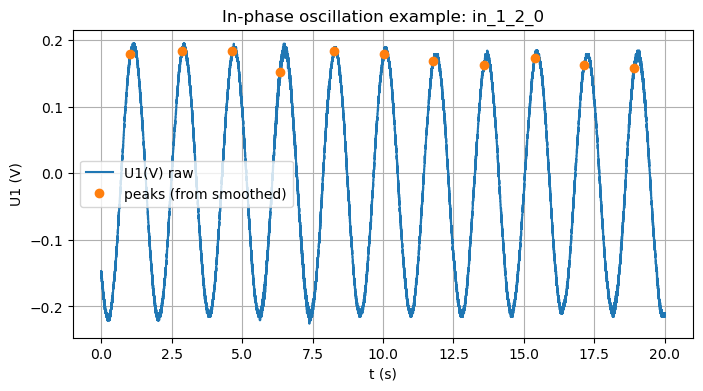

In [8]:
# Choose one run for illustration
example_name = "in_1_2_0"
t_ex, y_ex = runs[example_name]

# Estimate period and get peak positions
T_example, dT_example, peaks_example, y_ex_s = estimate_period_from_peaks(
    t_ex, y_ex, smooth_window=200, min_distance_factor=0.4
)
print(f"Estimated period for {example_name}: T = {T_example:.3f} s ± {dT_example:.3f} s")

# Plot with peaks (raw signal but peak positions from the smoothed signal)
plt.figure()
plt.plot(t_ex, y_ex, label="U1(V) raw")
plt.plot(t_ex[peaks_example], y_ex[peaks_example], "o", label="peaks (from smoothed)")
plt.xlabel("t (s)")
plt.ylabel("U1 (V)")
plt.title(f"In-phase oscillation example: {example_name}")
plt.legend()
plt.show()


In [10]:
spring_positions = [1, 3, 6]
angles_1 = [2, 4, 6]
angles_3 = [2, 4, 6]
angles_6 = [2, 3, 5]

def compute_mode_periods(mode_prefix, description, use_column="U1(V)"):
    """
    mode_prefix: 'in' or 'out'
    description: string for printing, e.g. 'In-phase (T1)'
    """
    print(f"\n==== {description} ({mode_prefix}_... files) ====\n")
    all_periods = {}

    for pos in spring_positions:
        periods_pos = []
        print(f"Spring position {pos}:")
        if pos == 1:
            angles = angles_1
        elif pos == 3 and mode_prefix == 'out':
            print("Special case for out-of-phase at position 3")
            angles = [2,3,5]
        elif pos == 3:
            angles = angles_3
        elif pos == 6:
            angles = angles_6
        
        for angle in angles:
            fname = f"{mode_prefix}_{pos}_{angle}_0"
            try:
                t, y = load_run(fname, use_column=use_column)
            except FileNotFoundError:
                print(f"  {fname}: file not found, skipping.")
                continue

            T_mean, T_std, peaks, y_s = estimate_period_from_peaks(
                t, y, smooth_window=200, min_distance_factor=0.4
            )
            peak_times = t[peaks]
            periods = np.diff(peak_times)

            periods_pos.append(periods)

            print(
                f"  {fname:15s}  T = {T_mean:6.3f} s  ± {T_std:6.3f} s  "
                f"(N periods = {len(periods)})"
            )

        if periods_pos:
            periods_pos = np.concatenate(periods_pos)
            all_periods[pos] = periods_pos
            print(
                f"  → Position {pos}:  ⟨T⟩ = {periods_pos.mean():6.3f} s  "
                f"± {periods_pos.std(ddof=1):6.3f} s\n"
            )
        else:
            print("  No valid files for this position.\n")

    return all_periods

# In-phase: T1
T1_periods = compute_mode_periods("in",  "In-phase oscillations T1")

# Out-of-phase: T2
T2_periods = compute_mode_periods("out", "Out-of-phase oscillations T2")



==== In-phase oscillations T1 (in_... files) ====

Spring position 1:
  in_1_2_0         T =  1.787 s  ±  0.057 s  (N periods = 10)
  in_1_4_0         T =  1.792 s  ±  0.013 s  (N periods = 10)
  in_1_6_0         T =  1.792 s  ±  0.007 s  (N periods = 10)
  → Position 1:  ⟨T⟩ =  1.790 s  ±  0.033 s

Spring position 3:
  in_3_2_0         T =  1.792 s  ±  0.011 s  (N periods = 11)
  in_3_4_0         T =  1.789 s  ±  0.015 s  (N periods = 10)
  in_3_6_0         T =  1.790 s  ±  0.006 s  (N periods = 10)
  → Position 3:  ⟨T⟩ =  1.790 s  ±  0.011 s

Spring position 6:
  in_6_2_0         T =  1.791 s  ±  0.028 s  (N periods = 10)
  in_6_3_0         T =  1.790 s  ±  0.026 s  (N periods = 10)
  in_6_5_0         T =  1.791 s  ±  0.012 s  (N periods = 10)
  → Position 6:  ⟨T⟩ =  1.790 s  ±  0.023 s


==== Out-of-phase oscillations T2 (out_... files) ====

Spring position 1:
  out_1_2_0        T =  1.766 s  ±  0.016 s  (N periods = 10)
  out_1_4_0        T =  1.769 s  ±  0.012 s  (N periods = 10

## 5. Determination of $T_1$ for all three in-phase runs

For **Task 1(a)**, we now determine the oscillation period $T_1$ of the
in-phase oscillations by averaging over all peak-to-peak time differences in
each run. We also compute a combined average over all three runs.


In [11]:
results = []  # (filename, T_mean, T_std, n_periods)
all_periods = []

for fname, (t, y) in runs.items():
    T_mean, T_std, peaks, y_s = estimate_period_from_peaks(
        t, y, smooth_window=200, min_distance_factor=0.4
    )
    n_periods = len(peaks) - 1
    results.append((fname, T_mean, T_std, n_periods))

    # Store all individual periods for the global average
    peak_times = t[peaks]
    all_periods.append(np.diff(peak_times))

print("Results for Task 1(a): In-phase period T1")
print("Filename    T_mean [s]   T_std [s]   #periods")
for fname, T_mean, T_std, n_periods in results:
    print(f"{fname:9s} {T_mean:10.4f} {T_std:10.4f} {n_periods:9d}")

all_periods = np.concatenate(all_periods)
T1_mean = all_periods.mean()
T1_std = all_periods.std(ddof=1)

print("\nCombined T1 from all in-phase runs (this spring position):")
print(f"T1 = {T1_mean:.3f} s ± {T1_std:.3f} s")


Results for Task 1(a): In-phase period T1
Filename    T_mean [s]   T_std [s]   #periods
in_1_6_0      1.7917     0.0066        10
in_1_4_0      1.7921     0.0126        10
in_1_2_0      1.7870     0.0568        10

Combined T1 from all in-phase runs (this spring position):
T1 = 1.790 s ± 0.033 s


## Calculation of Beat Period T_S

In [12]:
# Map spring positions to beat files
beat_files = {
    1: "beat_1_6_0",
    2: "beat_3_4_0",  # change this if your actual filename is different
    3: "beat_6_4_0",  # change this if needed
}


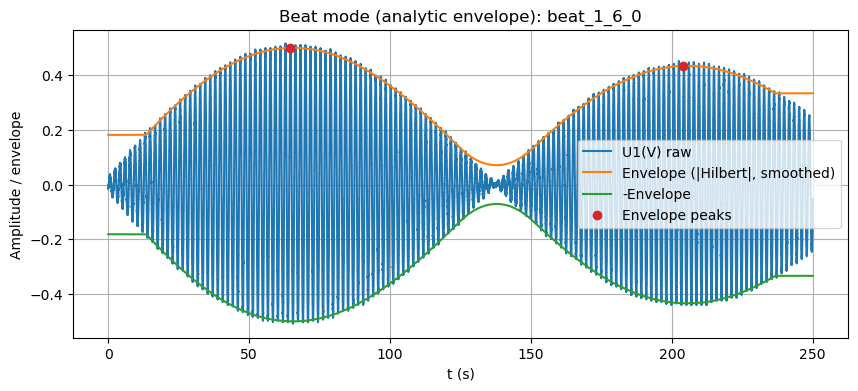

Estimated beat periods Ts (s): [139.7475]
Ts mean ± std: 139.748 ± nan s
Estimated fast period T ≈ 8.927 s


/home/skalv/miniforge3/envs/physics_lab/lib/python3.11/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/skalv/miniforge3/envs/physics_lab/lib/python3.11/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- helpers ----------
def hilbert_envelope(x: np.ndarray) -> np.ndarray:
    """Amplitude envelope via analytic signal (Hilbert) using FFT (no SciPy)."""
    x = np.asarray(x, dtype=float)
    N = x.size
    X = np.fft.fft(x)

    H = np.zeros(N)
    if N % 2 == 0:
        H[0] = 1.0
        H[N//2] = 1.0
        H[1:N//2] = 2.0
    else:
        H[0] = 1.0
        H[1:(N+1)//2] = 2.0

    z = np.fft.ifft(X * H)
    return np.abs(z)

def moving_mean(y, window):
    if window <= 1:
        return np.asarray(y)
    s = pd.Series(y).rolling(window=window, center=True).mean()
    s = s.bfill().ffill()
    return s.to_numpy()

def find_peaks_simple(y, height=None, min_distance=10):
    y = np.asarray(y)
    if height is None:
        height = np.median(y)
    peaks = []
    last = -min_distance
    for i in range(1, len(y)-1):
        if i - last < min_distance:
            continue
        if y[i] > height and y[i] > y[i-1] and y[i] >= y[i+1]:
            peaks.append(i)
            last = i
    return np.array(peaks, dtype=int)

def estimate_T_fast(t, y, smooth_window=200):
    """Fast-carrier period from smoothed peak-to-peak."""
    y_s = moving_mean(y, smooth_window)
    # pick a generous separation so we don't catch plateau wiggles
    approx_n_osc = 12
    base_distance = len(y) / approx_n_osc
    min_dist = max(int(base_distance * 0.4), 10)
    pk = find_peaks_simple(y_s, min_distance=min_dist)
    if len(pk) < 2:
        raise RuntimeError("Not enough peaks to estimate fast period.")
    dt = np.diff(t[pk])
    return dt.mean()

# ---------- load one beat file ----------
fname = "beat_1_6_0"   # change to beat_3_4_0 or beat_6_4_0 to test others
df = pd.read_csv(fname, sep="\t", decimal=",")
t  = df["t (s)"].to_numpy()
y1 = df["U1(V)"].to_numpy()
y1 = y1 - np.mean(y1)  # detrend

# ---------- compute true envelope ----------
env_raw = hilbert_envelope(y1)

# Smooth envelope slightly (a few carrier cycles, not the whole beat)
dt = t[1] - t[0]
T_fast = estimate_T_fast(t, y1, smooth_window=200)
win_env = int(max(3 * T_fast / dt, 101))  # ~3 cycles; ensure odd-ish & >=100
env = moving_mean(env_raw, win_env)

# Find envelope peaks with a large min_distance (~10 carrier periods)
min_dist_env = int(max(10 * T_fast / dt, 500))
env_peaks = find_peaks_simple(env, height=np.median(env), min_distance=min_dist_env)

# ---------- plot ----------
plt.figure(figsize=(10,4))
plt.plot(t, y1, label="U1(V) raw")
plt.plot(t,  env, label="Envelope (|Hilbert|, smoothed)")
plt.plot(t, -env, label="-Envelope")
plt.plot(t[env_peaks], env[env_peaks], "o", label="Envelope peaks")
plt.xlabel("t (s)")
plt.ylabel("Amplitude / envelope")
plt.title(f"Beat mode (analytic envelope): {fname}")
plt.grid(True)
plt.legend()
plt.show()

# Optional: print quick numbers
if len(env_peaks) >= 2:
    Ts = np.diff(t[env_peaks])
    print(f"Estimated beat periods Ts (s): {Ts}")
    print(f"Ts mean ± std: {Ts.mean():.3f} ± {Ts.std(ddof=1):.3f} s")
print(f"Estimated fast period T ≈ {T_fast:.3f} s")


T (fast) ≈ 0.991 s
Ts (beat) periods: [24.6825 24.63   25.085  24.9275 24.33   25.04   25.1375 24.7825 24.76  ]
Ts mean ± std: 24.819 ± 0.258 s


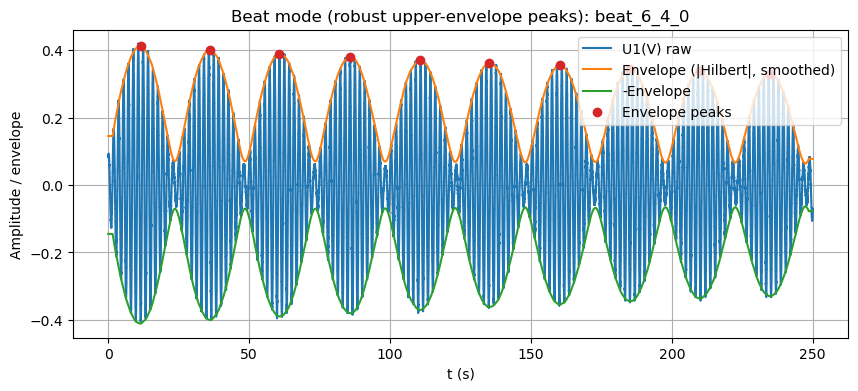

In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- Hilbert envelope (SciPy-free) ---
def hilbert_envelope(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float); N = x.size
    X = np.fft.fft(x)
    H = np.zeros(N)
    if N % 2 == 0: H[0]=1.0; H[N//2]=1.0; H[1:N//2]=2.0
    else:          H[0]=1.0; H[1:(N+1)//2]=2.0
    return np.abs(np.fft.ifft(X*H))

def moving_mean(y, w):
    if w <= 1: return np.asarray(y)
    s = pd.Series(y).rolling(window=int(w), center=True).mean()
    return s.bfill().ffill().to_numpy()

def fast_period_T(t, y, smooth_window=200):
    y_s = moving_mean(y, smooth_window)
    cand = np.where((y_s[1:-1] > y_s[:-2]) & (y_s[1:-1] >= y_s[2:]))[0] + 1
    if cand.size < 2: raise RuntimeError("Not enough peaks for T.")
    return np.diff(t[cand]).mean()

def coarse_Ts_autocorr(t, env, T_fast, dt):
    # mild detrend → clear slow oscillation
    env_d = env - moving_mean(env, max(len(env)//40, 201))
    env_d -= env_d.mean()
    ac = np.correlate(env_d, env_d, mode="full")[len(env_d)-1:]
    lag0 = int(3 * T_fast / dt)   # ignore carrier-scale lags
    lag = np.argmax(ac[lag0:]) + lag0
    return lag * dt, lag

def prominence_peaks_upper(env, lag_env, prom_frac=0.12):
    """
    Upper-envelope peaks using local prominence (robust to unequal lobe heights).
    prom_frac is fraction of (max(env)-min(env)) required as prominence.
    """
    y = env
    # 1) raw local maxima
    maxima = np.where((y[1:-1] > y[:-2]) & (y[1:-1] >= y[2:]))[0] + 1
    if maxima.size == 0: return np.array([], dtype=int)
    # 2) compute simple prominence in a ±W window (W ≈ half envelope period)
    W = max(int(0.5 * lag_env), 150)
    ymin, ymax = y.min(), y.max()
    thr_prom = prom_frac * (ymax - ymin)

    keep = []
    for i in maxima:
        lo = max(0, i - W); hi = min(len(y), i + W + 1)
        # nearest valley to left/right in the window
        left_min  = y[lo:i].min()  if i-lo > 1 else y[i]
        right_min = y[i+1:hi].min() if hi-(i+1) > 1 else y[i]
        prom = y[i] - max(left_min, right_min)
        if prom >= thr_prom:
            keep.append(i)
    peaks = np.array(keep, dtype=int)
    if peaks.size == 0: return peaks
    # 3) distance-based pruning (shorter than a full envelope period so we don't skip every other)
    min_dist = max(int(0.45 * lag_env), 180)  # 0.45 instead of 0.65
    order = np.argsort(y[peaks])[::-1]
    taken = np.zeros(len(y), dtype=bool)
    chosen = []
    for j in order:
        i = peaks[j]
        lo = max(0, i - min_dist); hi = min(len(y), i + min_dist + 1)
        if not taken[lo:hi].any():
            chosen.append(i); taken[lo:hi] = True
    chosen = np.sort(np.array(chosen, dtype=int))
    # 4) gap fill: if two consecutive peaks are >1.5 * lag_env apart, try to insert best missing max between them
    if chosen.size >= 2:
        filled = [chosen[0]]
        for a,b in zip(chosen[:-1], chosen[1:]):
            if (b - a) > int(1.5 * lag_env):
                mid_lo = a + int(0.35 * (b-a))
                mid_hi = b - int(0.35 * (b-a))
                k = mid_lo + np.argmax(y[mid_lo:mid_hi]) if mid_hi > mid_lo else None
                if k is not None and (y[k] - max(y[a], y[b]) * 0.0) > thr_prom/2:
                    filled.append(k)
            filled.append(b)
        chosen = np.array(sorted(filled), dtype=int)
    return chosen

# ---------------- choose file ----------------
fname = "beat_6_4_0"   # change to "beat_3_4_0" or "beat_6_4_0"
# ---------------------------------------------

# load + preprocess
df = pd.read_csv(fname, sep="\t", decimal=",")
t  = df["t (s)"].to_numpy()
y1 = df["U1(V)"].to_numpy() - df["U1(V)"].to_numpy().mean()
dt = t[1] - t[0]

# fast period
T_fast = fast_period_T(t, y1, smooth_window=200)

# analytic envelope and light smoothing (~3 fast periods)
env_raw = hilbert_envelope(y1)
win_env = int(max(3 * T_fast / dt, 101))
env = moving_mean(env_raw, win_env)

# coarse Ts and lag
Ts_est, lag_env = coarse_Ts_autocorr(t, env, T_fast, dt)

# robust upper-envelope peaks
pk = prominence_peaks_upper(env, lag_env, prom_frac=0.12)

# final Ts list
Ts_list = np.diff(t[pk]) if pk.size >= 2 else np.array([])
print(f"T (fast) ≈ {T_fast:.3f} s")
if Ts_list.size:
    print(f"Ts (beat) periods: {Ts_list}")
    print(f"Ts mean ± std: {Ts_list.mean():.3f} ± {Ts_list.std(ddof=1) if Ts_list.size>1 else 0:.3f} s")
else:
    print("Not enough envelope peaks—try prom_frac=0.10 or min_dist=0.40*lag_env.")

# plot
plt.figure(figsize=(10,4))
plt.plot(t, y1, label="U1(V) raw")
plt.plot(t,  env, label="Envelope (|Hilbert|, smoothed)")
plt.plot(t, -env, label="-Envelope")
if pk.size:
    plt.plot(t[pk], env[pk], "o", label="Envelope peaks")
plt.xlabel("t (s)"); plt.ylabel("Amplitude / envelope")
plt.title(f"Beat mode (robust upper-envelope peaks): {fname}")
plt.grid(True); plt.legend(); plt.show()


Envelope peaks at times (s): [ 10.0225  37.85    62.87    87.88   113.16   151.345  177.61   202.635
 228.2625]
Beat periods Ts (s): [27.8275 25.02   25.01   25.28   38.185  26.265  25.025  25.6275]
Ts mean ± std: 27.280 ± 4.509 s


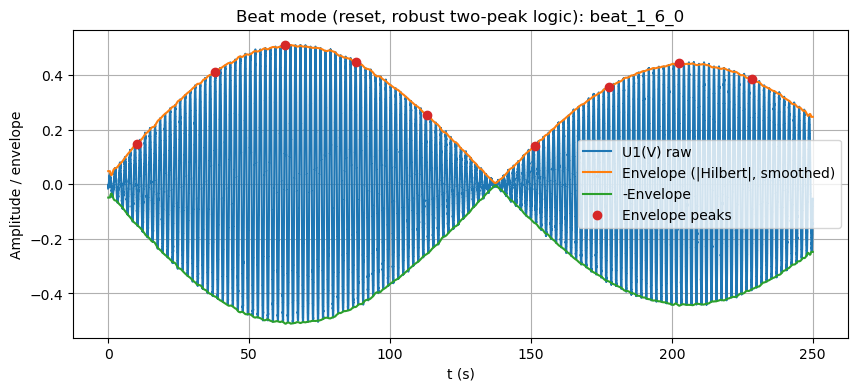

In [15]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# -------- Hilbert envelope (SciPy-free) --------
def hilbert_envelope(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float); N = x.size
    X = np.fft.fft(x)
    H = np.zeros(N)
    if N % 2 == 0: H[0]=1.0; H[N//2]=1.0; H[1:N//2]=2.0
    else:          H[0]=1.0; H[1:(N+1)//2]=2.0
    return np.abs(np.fft.ifft(X*H))

def moving_mean(y, w):
    if w <= 1: return np.asarray(y)
    s = pd.Series(y).rolling(window=int(w), center=True).mean()
    return s.bfill().ffill().to_numpy()

def local_maxima(y):
    """Indices of strict local maxima (no height threshold)."""
    y = np.asarray(y)
    return np.where((y[1:-1] > y[:-2]) & (y[1:-1] >= y[2:]))[0] + 1

def nms_by_distance(y, peaks, min_dist):
    """Non-maximum suppression by distance: keep highest within ±min_dist."""
    if len(peaks) == 0: return peaks
    order = np.argsort(y[peaks])[::-1]
    taken = np.zeros(len(y), dtype=bool)
    out = []
    for j in order:
        i = peaks[j]
        lo = max(0, i - min_dist); hi = min(len(y), i + min_dist + 1)
        if not taken[lo:hi].any():
            out.append(i)
            taken[lo:hi] = True
    return np.array(sorted(out), dtype=int)

def robust_env_peaks(t, env):
    """
    Robustly pick envelope peaks for very long beats:
    - find all local maxima on a smoothed Hilbert envelope
    - merge near duplicates using a distance tied to record length
    - ensure at least 2 peaks by picking global max + best in last third
    """
    N = len(t)
    Tspan = t[-1] - t[0]
    # distance scale: if there are ~2–8 lobes in 200–260 s, peak spacing is ~25–120 s.
    # In samples: use 5% of record as default, clamped between 150 and N/8.
    min_dist = int(np.clip(0.05 * N, 150, N//8))

    # raw maxima
    pk = local_maxima(env)
    # merge near-duplicates
    pk = nms_by_distance(env, pk, min_dist=min_dist)

    # guarantee at least two peaks for very long/weak beats
    if pk.size < 2:
        # global max
        g = int(np.argmax(env))
        # best in last third (avoid picking same spot)
        start_last_third = int(2*N/3)
        if start_last_third <= g:  # if global max is already late, use first third
            start_last_third = 0
        lo = max(start_last_third, 0)
        if N - lo >= 5:
            k2 = lo + int(np.argmax(env[lo:]))
        else:
            k2 = g
        pk = np.unique(np.array([g, k2], dtype=int))

    # final sort and prune too-close duplicates again (edge case)
    pk = np.array(sorted(pk), dtype=int)
    pruned = [pk[0]]
    for i in pk[1:]:
        if i - pruned[-1] >= min_dist:
            pruned.append(i)
    return np.array(pruned, dtype=int)

# -------------- choose file --------------
fname = "beat_1_6_0"  # or "beat_3_4_0", "beat_6_4_0"
# ----------------------------------------

# load
df = pd.read_csv(fname, sep="\t", decimal=",")
t  = df["t (s)"].to_numpy()
y1 = df["U1(V)"].to_numpy()
y1 = y1 - y1.mean()
dt = t[1] - t[0]

# envelope + light smoothing (~3 carrier periods); carrier ~1.8 s → ~3*1.8/dt samples
# if you already estimated T_fast, you can compute this exactly; a fixed wide window also works:
smooth_win = 500  # works well on your data for envelope, too
env = moving_mean(hilbert_envelope(y1), smooth_win)

# robust peaks
env_peaks = robust_env_peaks(t, env)

# beat periods
Ts = np.diff(t[env_peaks]) if env_peaks.size >= 2 else np.array([])

print(f"Envelope peaks at times (s): {t[env_peaks]}")
if Ts.size:
    print(f"Beat periods Ts (s): {Ts}")
    print(f"Ts mean ± std: {Ts.mean():.3f} ± {Ts.std(ddof=1) if Ts.size>1 else 0:.3f} s")

# plot
plt.figure(figsize=(10,4))
plt.plot(t, y1, label="U1(V) raw")
plt.plot(t,  env, label="Envelope (|Hilbert|, smoothed)")
plt.plot(t, -env, label="-Envelope")
if env_peaks.size:
    plt.plot(t[env_peaks], env[env_peaks], "o", label="Envelope peaks")
plt.xlabel("t (s)"); plt.ylabel("Amplitude / envelope")
plt.title(f"Beat mode (reset, robust two-peak logic): {fname}")
plt.grid(True); plt.legend(); plt.show()


## 6. Summary for the protocol

For the analysed spring position (FS = 1) and the three in-phase measurements
with different initial angles, we obtain:

- Individual in-phase periods $T_1$ for each run (see printed table above),
- A combined mean value
  \[ T_1 = T_\text{mean} \pm \Delta T \]
  where $T_\text{mean}$ is the mean of all peak-to-peak intervals and
  $\Delta T$ is their standard deviation.

You can copy this section into your lab protocol, together with

- the example time-series plot with marked peaks and
- a short explanation of the method:
  *“$T_1$ is obtained as the average time difference between successive maxima
  of the in-phase oscillation signal $U_1(t)$, where the maxima are determined
  from a smoothed version of the signal to suppress noise on the plateau.”*

---

### How to extend this notebook

- For **Task 1(b)** (out-of-phase), repeat the same analysis with the
  corresponding `out_...` files.
- For **Task 1(c–d)** (beat oscillations and beat period), you can adapt the
  analysis to find maxima of the *envelope* or use minima in the energy
  exchange between the two pendulums.
- The resulting $T_1$ and $T_2$ can then be used directly in **Tasks 2–4**
  of the question sheet.
